In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("nepal-earthquake-severity-index-latest.csv")

df.head()

,P_CODE,VDC_NAME,DISTRICT,REGION,Hazard (Intensity),Exposure,Housing,Poverty,Vulnerability,Severity,Severity Normalized,Severity category
0,C-BAG-27-031,KathmanduN.P.,Kathmandu,Central,2.17,10.00,8.86,1.82,5.34,4.88,10.0000,Highest
1,C-BAG-25-027,LalitpurN.P.,Lalitpur,Central,1.72,2.26,8.40,0.82,4.61,2.62,5.3707,Highest
2,C-NAR-35-005,BharatpurN. P.,Chitawan,Central,2.21,1.47,5.38,2.53,3.96,2.34,4.8083,Highest
3,C-BAG-26-012,MadhyapurThimiN.P.,Bhaktapur,Central,2.45,0.85,8.23,0.89,4.56,2.12,4.3447,Highest
4,C-BAG-27-028,Jorpati,Kathmandu,Central,1.91,0.87,8.86,1.82,5.34,2.07,4.2407,Highest


In [3]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3986 entries, 0 to 3985
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   P_CODE               3985 non-null   object 
 1   VDC_NAME             3985 non-null   object 
 2   DISTRICT             3985 non-null   object 
 3   REGION               3985 non-null   object 
 4   Hazard (Intensity)   3985 non-null   float64
 5   Exposure             3985 non-null   float64
 6   Housing              3985 non-null   float64
 7   Poverty              3985 non-null   float64
 8   Vulnerability        3985 non-null   float64
 9   Severity             3985 non-null   float64
 10  Severity Normalized  3985 non-null   float64
 11  Severity category    3985 non-null   object 
dtypes: float64(7), object(5)
memory usage: 373.8+ KB


In [4]:
df.duplicated().sum()

0

Home page kpi values

In [5]:
df["P_CODE"].nunique()

3985

In [6]:
df["DISTRICT"].nunique()

75

In [7]:
df["REGION"].nunique()

5

In [8]:
df["Severity"].mean()

0.24872020075282308

In [9]:
df["Severity"].max()

4.88

In [10]:
#most risky district
df.groupby("DISTRICT")["Severity"].mean().sort_values(ascending=False).head(1)

DISTRICT
Bhaktapur    1.014444
Name: Severity, dtype: float64

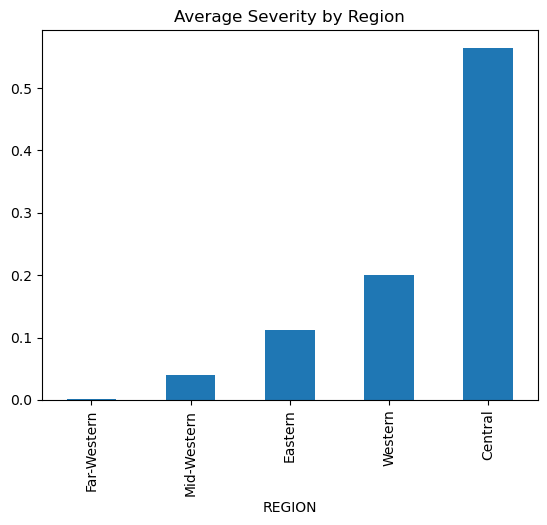

In [11]:
df.groupby("REGION")["Severity"].mean().sort_values().plot(kind="bar")
plt.title("Average Severity by Region")
plt.show()

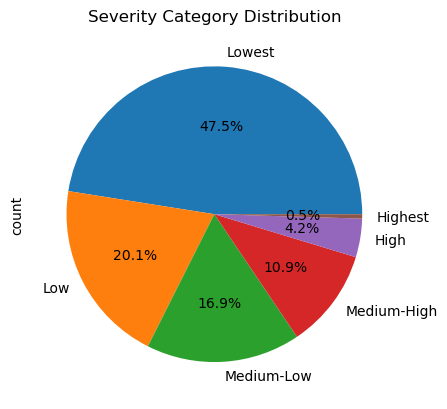

In [12]:
df["Severity category"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Severity Category Distribution")
plt.show()

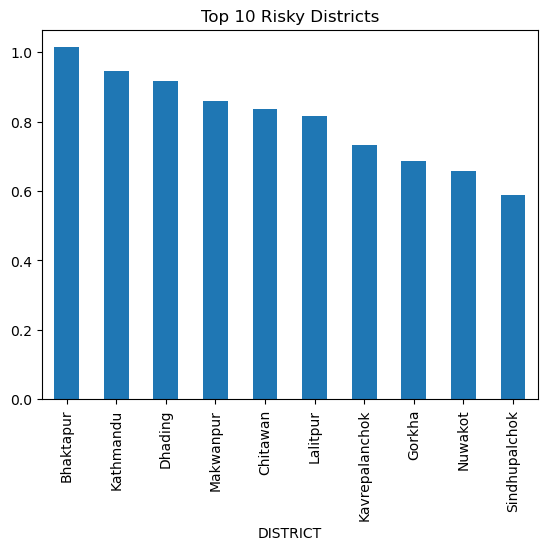

In [13]:
df.groupby("DISTRICT")["Severity"].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Risky Districts")
plt.show()

In [14]:
top_risky = df.groupby("DISTRICT")["Severity"].mean().sort_values(ascending=False).head(10)
top_risky

DISTRICT
Bhaktapur         1.014444
Kathmandu         0.946780
Dhading           0.918400
Makwanpur         0.859545
Chitawan          0.836410
Lalitpur          0.815000
Kavrepalanchok    0.731556
Gorkha            0.687612
Nuwakot           0.656290
Sindhupalchok     0.589620
Name: Severity, dtype: float64

------------2 --------------

In [15]:
# unique region
df["REGION"].unique()

array(['Central', 'Western', 'Eastern', 'Mid-Western', 'Far-Western', nan],
      dtype=object)

In [16]:
df["Severity category"].unique()

array(['Highest', 'High', 'Medium-High', 'Medium-Low', 'Low', 'Lowest',
       nan], dtype=object)

Pretend user selected:

REGION = Central
Severity = High

In [17]:
#filter by region
central_df = df[df["REGION"] == "Central"]

central_df.head()

,P_CODE,VDC_NAME,DISTRICT,REGION,Hazard (Intensity),Exposure,Housing,Poverty,Vulnerability,Severity,Severity Normalized,Severity category
0,C-BAG-27-031,KathmanduN.P.,Kathmandu,Central,2.17,10.00,8.86,1.82,5.34,4.88,10.0000,Highest
1,C-BAG-25-027,LalitpurN.P.,Lalitpur,Central,1.72,2.26,8.40,0.82,4.61,2.62,5.3707,Highest
2,C-NAR-35-005,BharatpurN. P.,Chitawan,Central,2.21,1.47,5.38,2.53,3.96,2.34,4.8083,Highest
3,C-BAG-26-012,MadhyapurThimiN.P.,Bhaktapur,Central,2.45,0.85,8.23,0.89,4.56,2.12,4.3447,Highest
4,C-BAG-27-028,Jorpati,Kathmandu,Central,1.91,0.87,8.86,1.82,5.34,2.07,4.2407,Highest


In [18]:
# filter by severity score
high_df = df[df["Severity category"] == "High"]

high_df.head()

,P_CODE,VDC_NAME,DISTRICT,REGION,Hazard (Intensity),Exposure,Housing,Poverty,Vulnerability,Severity,Severity Normalized,Severity category
19,C-BAG-27-016,Dhapasi,Kathmandu,Central,1.74,0.32,8.86,1.82,5.34,1.44,2.9542,High
20,C-BAG-27-023,Gothatar,Kathmandu,Central,2.00,0.27,8.86,1.82,5.34,1.42,2.9142,High
21,W-LUM-48-021,Gaidakot,Nawalparasi,Western,1.82,0.34,5.61,3.51,4.56,1.42,2.9061,High
22,C-BAG-24-006,BanepaN. P.,Kavrepalanchok,Central,2.28,0.25,6.46,3.31,4.88,1.41,2.8980,High
23,C-JAN-20-013,Dadiguranshe,Sindhuli,Central,9.30,0.05,5.19,6.55,5.87,1.39,2.8516,High


In [19]:
#Combine BOTH filters
filtered_df = df[
    (df["REGION"] == "Central") &
    (df["Severity category"] == "High")
]

filtered_df.head()

,P_CODE,VDC_NAME,DISTRICT,REGION,Hazard (Intensity),Exposure,Housing,Poverty,Vulnerability,Severity,Severity Normalized,Severity category
19,C-BAG-27-016,Dhapasi,Kathmandu,Central,1.74,0.32,8.86,1.82,5.34,1.44,2.9542,High
20,C-BAG-27-023,Gothatar,Kathmandu,Central,2.00,0.27,8.86,1.82,5.34,1.42,2.9142,High
22,C-BAG-24-006,BanepaN. P.,Kavrepalanchok,Central,2.28,0.25,6.46,3.31,4.88,1.41,2.8980,High
23,C-JAN-20-013,Dadiguranshe,Sindhuli,Central,9.30,0.05,5.19,6.55,5.87,1.39,2.8516,High
24,C-BAG-27-038,Manmaiju,Kathmandu,Central,1.20,0.41,8.86,1.82,5.34,1.39,2.8434,High


In [20]:
#Decide what columns to show in table
filtered_df[
    [
        "VDC_NAME",
        "DISTRICT",
        "REGION",
        "Hazard (Intensity)",
        "Exposure",
        "Vulnerability",
        "Severity",
        "Severity category"
    ]
]

,VDC_NAME,DISTRICT,REGION,Hazard (Intensity),Exposure,Vulnerability,Severity,Severity category
19,Dhapasi,Kathmandu,Central,1.74,0.32,5.34,1.44,High
20,Gothatar,Kathmandu,Central,2.00,0.27,5.34,1.42,High
22,BanepaN. P.,Kavrepalanchok,Central,2.28,0.25,4.88,1.41,High
23,Dadiguranshe,Sindhuli,Central,9.30,0.05,5.87,1.39,High
24,Manmaiju,Kathmandu,Central,1.20,0.41,5.34,1.39,High
...,...,...,...,...,...,...,...,...
182,Dandakharka,Makwanpur,Central,3.46,0.04,4.32,0.85,High
183,Basamadi,Makwanpur,Central,0.81,0.18,4.32,0.85,High
184,Lakhanpur,Ramechhap,Central,1.46,0.06,6.61,0.85,High
185,Fakhel,Makwanpur,Central,3.04,0.05,4.32,0.85,High


STEP 4 — Small Analysis on Filtered Data

This is important because later Streamlit charts will use filtered data.

In [21]:
#Average Severity in filtered data
filtered_df["Severity"].mean()

1.0196688741721853

In [22]:
#Top risky districts in selected region
filtered_df.groupby("DISTRICT")["Severity"].mean().sort_values(ascending=False)

DISTRICT
Dhading           1.100690
Dolakha           1.100000
Kathmandu         1.056316
Lalitpur          1.028182
Chitawan          1.019412
Kavrepalanchok    1.009375
Nuwakot           1.002500
Bhaktapur         0.993333
Mahottari         0.990000
Sindhupalchok     0.990000
Sindhuli          0.975000
Makwanpur         0.956957
Parsa             0.950000
Sarlahi           0.950000
Dhanusa           0.920000
Rautahat          0.880000
Ramechhap         0.850000
Name: Severity, dtype: float64

In [23]:
#Count of severity categories by region
df.groupby("REGION")["Severity category"].value_counts()

REGION       Severity category
Central      Medium-Low           565
             Medium-High          381
             High                 151
             Low                  105
             Highest               17
             Lowest                 2
Eastern      Lowest               521
             Low                  368
             Medium-Low            20
Far-Western  Lowest               394
Mid-Western  Lowest               565
             Low                   17
Western      Lowest               411
             Low                  310
             Medium-Low            87
             Medium-High           52
             High                  17
             Highest                2
Name: count, dtype: int64

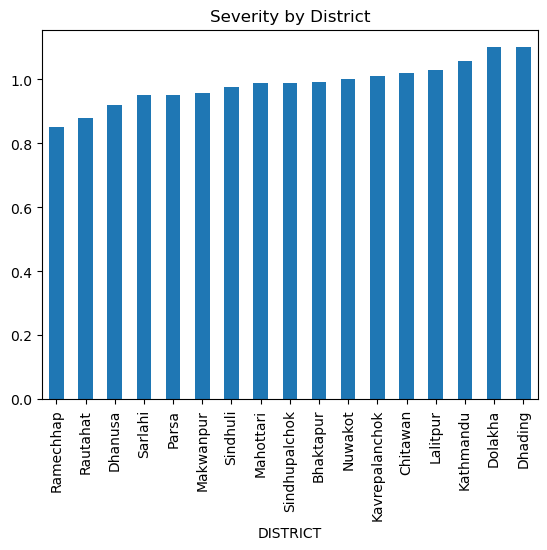

In [24]:
#Severity by District
filtered_df.groupby("DISTRICT")["Severity"].mean().sort_values().plot(kind="bar")
plt.title("Severity by District")
plt.show()

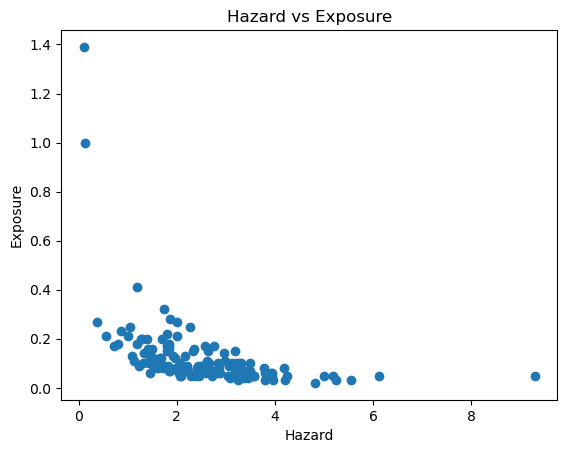

In [25]:
#Hazard vs Exposure
plt.scatter(filtered_df["Hazard (Intensity)"], filtered_df["Exposure"])
plt.xlabel("Hazard")
plt.ylabel("Exposure")
plt.title("Hazard vs Exposure")
plt.show()

---------------3----------------

In [26]:
df["Severity"].describe()

count    3985.000000
mean        0.248720
std         0.298756
min         0.000000
25%         0.050000
50%         0.140000
75%         0.360000
max         4.880000
Name: Severity, dtype: float64

In [27]:
df.sort_values(by="Severity", ascending=False).head(10)

,P_CODE,VDC_NAME,DISTRICT,REGION,Hazard (Intensity),Exposure,Housing,Poverty,Vulnerability,Severity,Severity Normalized,Severity category
0,C-BAG-27-031,KathmanduN.P.,Kathmandu,Central,2.17,10.00,8.86,1.82,5.34,4.88,10.0000,Highest
1,C-BAG-25-027,LalitpurN.P.,Lalitpur,Central,1.72,2.26,8.40,0.82,4.61,2.62,5.3707,Highest
2,C-NAR-35-005,BharatpurN. P.,Chitawan,Central,2.21,1.47,5.38,2.53,3.96,2.34,4.8083,Highest
3,C-BAG-26-012,MadhyapurThimiN.P.,Bhaktapur,Central,2.45,0.85,8.23,0.89,4.56,2.12,4.3447,Highest
4,C-BAG-27-028,Jorpati,Kathmandu,Central,1.91,0.87,8.86,1.82,5.34,2.07,4.2407,Highest
5,C-BAG-26-003,BhaktapurN.P.,Bhaktapur,Central,1.82,0.84,8.23,0.89,4.56,1.91,3.9135,Highest
6,W-GAN-36-050,PrithbinarayanN.P.,Gorkha,Western,3.48,0.33,6.44,5.21,5.83,1.89,3.8764,Highest
7,C-JAN-20-025,KamalamiN.P.,Sindhuli,Central,2.54,0.40,5.19,6.55,5.87,1.82,3.7307,Highest
8,C-JAN-20-026,Kapilakot,Sindhuli,Central,8.02,0.12,5.19,6.55,5.87,1.77,3.6294,Highest
9,C-BAG-27-033,KirtipurN.P.,Kathmandu,Central,1.35,0.67,8.86,1.82,5.34,1.69,3.4689,Highest


In [28]:
district_risk = (
    df.groupby("DISTRICT")["Severity"]
    .mean()
    .sort_values(ascending=False)
)

district_risk.head(10)

DISTRICT
Bhaktapur         1.014444
Kathmandu         0.946780
Dhading           0.918400
Makwanpur         0.859545
Chitawan          0.836410
Lalitpur          0.815000
Kavrepalanchok    0.731556
Gorkha            0.687612
Nuwakot           0.656290
Sindhupalchok     0.589620
Name: Severity, dtype: float64

In [29]:
#converting in proper table
top_districts = district_risk.head(10).reset_index()

top_districts

,DISTRICT,Severity
0,Bhaktapur,1.014444
1,Kathmandu,0.946780
2,Dhading,0.918400
3,Makwanpur,0.859545
4,Chitawan,0.836410
5,Lalitpur,0.815000
6,Kavrepalanchok,0.731556
7,Gorkha,0.687612
8,Nuwakot,0.656290
9,Sindhupalchok,0.589620


In [30]:
df[["DISTRICT", "REGION"]].drop_duplicates()

,DISTRICT,REGION
0,Kathmandu,Central
1,Lalitpur,Central
2,Chitawan,Central
3,Bhaktapur,Central
6,Gorkha,Western
...,...,...
3522,Baitadi,Far-Western
3694,Kanchanpur,Far-Western
3695,Kailali,Far-Western
3710,Arghakhanchi,Western


In [31]:
region_map = df[["DISTRICT", "REGION"]].drop_duplicates()

top_districts = top_districts.merge(region_map, on="DISTRICT")

top_districts

,DISTRICT,Severity,REGION
0,Bhaktapur,1.014444,Central
1,Kathmandu,0.946780,Central
2,Dhading,0.918400,Central
3,Makwanpur,0.859545,Central
4,Chitawan,0.836410,Central
5,Lalitpur,0.815000,Central
6,Kavrepalanchok,0.731556,Central
7,Gorkha,0.687612,Western
8,Nuwakot,0.656290,Central
9,Sindhupalchok,0.589620,Central


Which regions of Nepal are generally more at risk?”

In [32]:
region_summary = df.groupby("REGION").agg({
    "Severity": "mean",
    "Hazard (Intensity)": "mean",
    "Exposure": "mean",
    "Vulnerability": "mean",
    "P_CODE": "count"
}).rename(columns={"P_CODE": "Total Areas"})

region_summary.sort_values("Severity", ascending=False)

,Severity,Hazard (Intensity),Exposure,Vulnerability,Total Areas
REGION,,,,,
Central,0.564660,0.900491,0.080082,5.892858,1221
Western,0.200978,0.189750,0.056917,4.996018,879
Eastern,0.111397,0.012101,0.065259,4.444422,909
Mid-Western,0.040412,0.000086,0.061667,6.529175,582
Far-Western,0.000660,0.000000,0.065838,7.279137,394


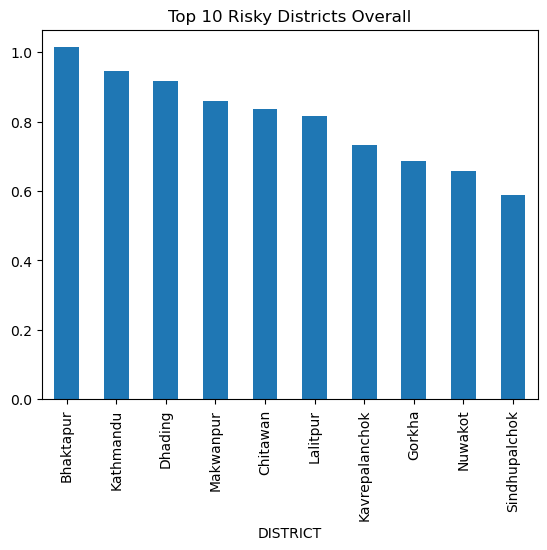

In [33]:
top_districts = df.groupby("DISTRICT")["Severity"].mean().sort_values(ascending=False).head(10)

top_districts.plot(kind="bar")
plt.title("Top 10 Risky Districts Overall")
plt.show()

In [34]:
top_10_risky = df.sort_values(by="Severity", ascending=False).head(10)

top_10_risky

,P_CODE,VDC_NAME,DISTRICT,REGION,Hazard (Intensity),Exposure,Housing,Poverty,Vulnerability,Severity,Severity Normalized,Severity category
0,C-BAG-27-031,KathmanduN.P.,Kathmandu,Central,2.17,10.00,8.86,1.82,5.34,4.88,10.0000,Highest
1,C-BAG-25-027,LalitpurN.P.,Lalitpur,Central,1.72,2.26,8.40,0.82,4.61,2.62,5.3707,Highest
2,C-NAR-35-005,BharatpurN. P.,Chitawan,Central,2.21,1.47,5.38,2.53,3.96,2.34,4.8083,Highest
3,C-BAG-26-012,MadhyapurThimiN.P.,Bhaktapur,Central,2.45,0.85,8.23,0.89,4.56,2.12,4.3447,Highest
4,C-BAG-27-028,Jorpati,Kathmandu,Central,1.91,0.87,8.86,1.82,5.34,2.07,4.2407,Highest
5,C-BAG-26-003,BhaktapurN.P.,Bhaktapur,Central,1.82,0.84,8.23,0.89,4.56,1.91,3.9135,Highest
6,W-GAN-36-050,PrithbinarayanN.P.,Gorkha,Western,3.48,0.33,6.44,5.21,5.83,1.89,3.8764,Highest
7,C-JAN-20-025,KamalamiN.P.,Sindhuli,Central,2.54,0.40,5.19,6.55,5.87,1.82,3.7307,Highest
8,C-JAN-20-026,Kapilakot,Sindhuli,Central,8.02,0.12,5.19,6.55,5.87,1.77,3.6294,Highest
9,C-BAG-27-033,KirtipurN.P.,Kathmandu,Central,1.35,0.67,8.86,1.82,5.34,1.69,3.4689,Highest


In [35]:
bottom_10_safe = df.sort_values(by="Severity", ascending=True).head(10)



In [36]:
top_10_risky[[
    "VDC_NAME",
    "DISTRICT",
    "REGION",
    "Hazard (Intensity)",
    "Exposure",
    "Vulnerability",
    "Severity",
    "Severity category"
]]

,VDC_NAME,DISTRICT,REGION,Hazard (Intensity),Exposure,Vulnerability,Severity,Severity category
0,KathmanduN.P.,Kathmandu,Central,2.17,10.00,5.34,4.88,Highest
1,LalitpurN.P.,Lalitpur,Central,1.72,2.26,4.61,2.62,Highest
2,BharatpurN. P.,Chitawan,Central,2.21,1.47,3.96,2.34,Highest
3,MadhyapurThimiN.P.,Bhaktapur,Central,2.45,0.85,4.56,2.12,Highest
4,Jorpati,Kathmandu,Central,1.91,0.87,5.34,2.07,Highest
5,BhaktapurN.P.,Bhaktapur,Central,1.82,0.84,4.56,1.91,Highest
6,PrithbinarayanN.P.,Gorkha,Western,3.48,0.33,5.83,1.89,Highest
7,KamalamiN.P.,Sindhuli,Central,2.54,0.40,5.87,1.82,Highest
8,Kapilakot,Sindhuli,Central,8.02,0.12,5.87,1.77,Highest
9,KirtipurN.P.,Kathmandu,Central,1.35,0.67,5.34,1.69,Highest


In [37]:
bottom_10_safe[[
    "VDC_NAME",
    "DISTRICT",
    "REGION",
    "Severity",
    "Severity category"
]]

,VDC_NAME,DISTRICT,REGION,Severity,Severity category
3984,Lumbini Development,Rupandehi,Western,0.0,Lowest
3534,Hemantabada,Bajhang,Far-Western,0.0,Lowest
3533,Ganapur,Banke,Mid-Western,0.0,Lowest
3532,KalBhairab,Dailekh,Mid-Western,0.0,Lowest
3531,Chaudhari,Bajhang,Far-Western,0.0,Lowest
3530,NauleKatuwal,Dailekh,Mid-Western,0.0,Lowest
3529,Maulali,Bajhang,Far-Western,0.0,Lowest
3528,Dhirkamandau,Doti,Far-Western,0.0,Lowest
3527,Paraspur,Banke,Mid-Western,0.0,Lowest
3526,Kumalgaun,Kalikot,Mid-Western,0.0,Lowest


In [38]:
# places with strongest earthquake hazard
df.sort_values("Hazard (Intensity)", ascending=False).head(10)

,P_CODE,VDC_NAME,DISTRICT,REGION,Hazard (Intensity),Exposure,Housing,Poverty,Vulnerability,Severity,Severity Normalized,Severity category
13,C-JAN-20-034,Mahadevsthan,Sindhuli,Central,10.00,0.07,5.19,6.55,5.87,1.61,3.3070,Highest
23,C-JAN-20-013,Dadiguranshe,Sindhuli,Central,9.30,0.05,5.19,6.55,5.87,1.39,2.8516,High
8,C-JAN-20-026,Kapilakot,Sindhuli,Central,8.02,0.12,5.19,6.55,5.87,1.77,3.6294,Highest
14,C-JAN-20-024,Kalpabrishykha,Sindhuli,Central,7.10,0.10,5.19,6.55,5.87,1.59,3.2566,Highest
48,C-BAG-24-032,Gokule,Kavrepalanchok,Central,6.13,0.05,6.46,3.31,4.88,1.14,2.3398,High
121,C-BAG-24-018,Dandagaun,Kavrepalanchok,Central,5.55,0.03,6.46,3.31,4.88,0.95,1.9524,High
122,C-JAN-20-045,Santeswori(Rampur),Sindhuli,Central,5.25,0.03,5.19,6.55,5.87,0.95,1.9507,High
92,C-NAR-35-009,Dahakhani,Chitawan,Central,5.18,0.05,5.38,2.53,3.96,1.00,2.0565,High
91,C-NAR-35-008,ChandiBhanjyang,Chitawan,Central,5.00,0.05,5.38,2.53,3.96,1.00,2.0572,High
169,C-JAN-20-001,Amale,Sindhuli,Central,4.82,0.02,5.19,6.55,5.87,0.87,1.7822,High


In [39]:
df.groupby("DISTRICT")["Hazard (Intensity)"].mean().sort_values(ascending=False).head(10)

DISTRICT
Makwanpur         2.450909
Lalitpur          2.427619
Kavrepalanchok    2.254556
Dhading           2.080200
Bhaktapur         1.982778
Chitawan          1.715385
Sindhuli          1.628148
Gorkha            1.611194
Kathmandu         1.426780
Nuwakot           1.180806
Name: Hazard (Intensity), dtype: float64

In [40]:
df.groupby("REGION")["Hazard (Intensity)"].mean().sort_values(ascending=False)

REGION
Central        0.900491
Western        0.189750
Eastern        0.012101
Mid-Western    0.000086
Far-Western    0.000000
Name: Hazard (Intensity), dtype: float64

<Axes: xlabel='Hazard (Intensity)', ylabel='Severity'>

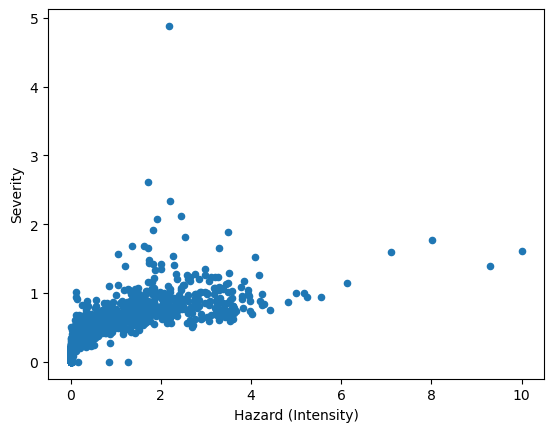

In [41]:
# hazard vs severity
df.plot.scatter(x="Hazard (Intensity)", y="Severity")

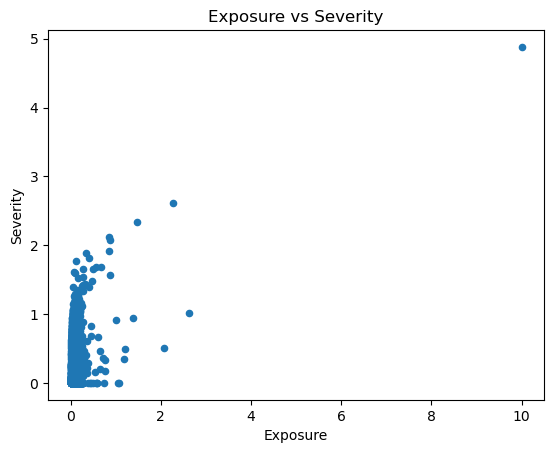

In [42]:
#exposure vs severty
#“Do crowded areas suffer more damage?”
df.plot.scatter(x="Exposure", y="Severity")
plt.title("Exposure vs Severity")
plt.show()

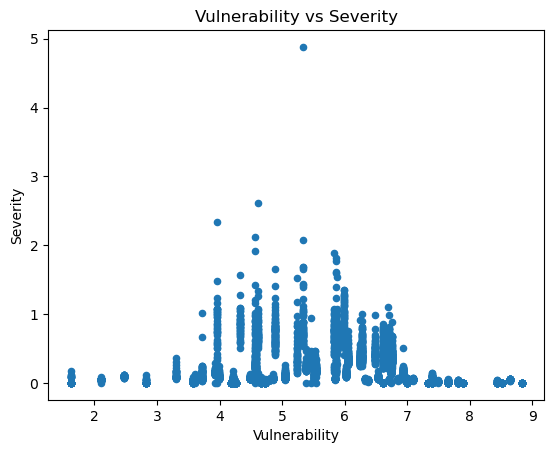

In [43]:
#“Do weak areas get more damaged?”    VULNERABILITY vs SEVERITY
df.plot.scatter(x="Vulnerability", y="Severity")
plt.title("Vulnerability vs Severity")
plt.show()


In [44]:
df[df["Vulnerability"] >= 4][["Exposure", "Severity"]].describe()


,Exposure,Severity
count,3401.000000,3401.000000
mean,0.067415,0.267648
std,0.194358,0.305777
min,0.000000,0.000000
25%,0.030000,0.050000
50%,0.050000,0.170000
75%,0.070000,0.400000
max,10.000000,4.880000


In [45]:
df[df["Vulnerability"] <= 2][["Exposure", "Severity"]].describe()

,Exposure,Severity
count,50.000000,50.000000
mean,0.166000,0.019200
std,0.131009,0.043087
min,0.040000,0.000000
25%,0.100000,0.000000
50%,0.130000,0.000000
75%,0.190000,0.000000
max,0.770000,0.180000


In [46]:
df[["Hazard (Intensity)", "Exposure", "Vulnerability", "Severity"]].corr()

,Hazard (Intensity),Exposure,Vulnerability,Severity
Hazard (Intensity),1.000000,0.050973,-0.058888,0.778000
Exposure,0.050973,1.000000,-0.040332,0.350456
Vulnerability,-0.058888,-0.040332,1.000000,-0.013060
Severity,0.778000,0.350456,-0.013060,1.000000


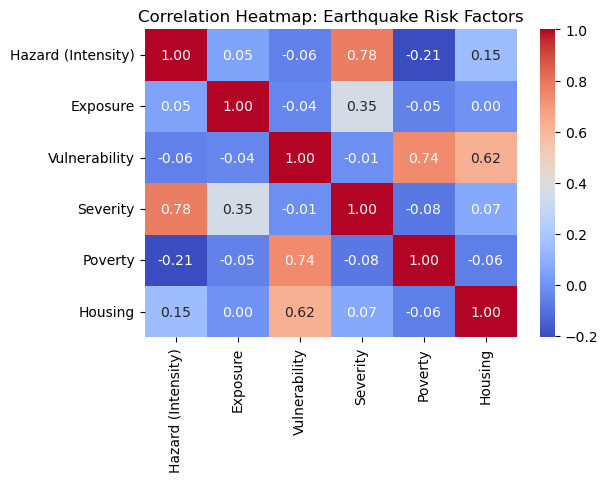

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only important numeric columns
cols = ["Hazard (Intensity)", "Exposure", "Vulnerability", "Severity",'Poverty','Housing']

corr = df[cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap: Earthquake Risk Factors")
plt.show()

-------------------4-----------------------

In [48]:

print("Number of duplicate rows:", df.duplicated().sum())


df = df.drop_duplicates()

Number of duplicate rows: 0


In [49]:
print("Number of missing districts:", df["DISTRICT"].isnull().sum())

Number of missing districts: 1


In [50]:
# This filters your data to show only the row(s) where DISTRICT is empty
df[df["DISTRICT"].isnull()]

,P_CODE,VDC_NAME,DISTRICT,REGION,Hazard (Intensity),Exposure,Housing,Poverty,Vulnerability,Severity,Severity Normalized,Severity category
3985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


since only one row is there where district is empty we will drop it

In [51]:
# Drops ONLY rows where the DISTRICT cell is empty
df = df.dropna(subset=["DISTRICT"])

In [52]:
# Display the unique districts so you can pick one to test with
print("Available Districts:")
print(df["DISTRICT"].unique()[:10])

Available Districts:
['Kathmandu' 'Lalitpur' 'Chitawan' 'Bhaktapur' 'Gorkha' 'Sindhuli'
 'Kavrepalanchok' 'Makwanpur' 'Nuwakot' 'Tanahu']


In [53]:
# Choose a test district to verify the calculations work
test_district = "Kathmandu"

# 1. Filter down to just this district
district_df = df[df["DISTRICT"] == test_district]

# 2. Calculate the averages for our 4 summary cards
avg_severity = district_df["Severity"].mean()
avg_hazard = district_df["Hazard (Intensity)"].mean()
avg_housing = district_df["Housing"].mean()
total_local_units = district_df["VDC_NAME"].nunique()

print(f"--- {test_district} District Summary ---")
print(f"Average Severity Score: {avg_severity:.2f}")
print(f"Average Hazard Intensity: {avg_hazard:.2f}")
print(f"Average Housing Vulnerability: {avg_housing:.2f}")
print(f"Total Local Units (Municipalities/VDCs): {total_local_units}")

--- Kathmandu District Summary ---
Average Severity Score: 0.95
Average Hazard Intensity: 1.43
Average Housing Vulnerability: 8.86
Total Local Units (Municipalities/VDCs): 59


In [54]:
# Select only our streamlined, important columns
important_cols = [
    "VDC_NAME", 
    "REGION", 
    "Hazard (Intensity)", 
    "Exposure", 
    "Housing", 
    "Poverty", 
    "Severity", 
    "Severity category"
]

# Rename 'VDC_NAME' to 'Local Unit (Municipality/VDC)' so it looks professional
clean_table = district_df[important_cols].rename(
    columns={"VDC_NAME": "Local Unit (Municipality/VDC)"}
)

# Sort strictly by Severity Score from Highest to Lowest
clean_table_sorted = clean_table.sort_values(by="Severity", ascending=False)

# Look at the top 5 worst-hit local units in your notebook
clean_table_sorted.head(5)

,Local Unit (Municipality/VDC),REGION,Hazard (Intensity),Exposure,Housing,Poverty,Severity,Severity category
0,KathmanduN.P.,Central,2.17,10.00,8.86,1.82,4.88,Highest
4,Jorpati,Central,1.91,0.87,8.86,1.82,2.07,Highest
9,KirtipurN.P.,Central,1.35,0.67,8.86,1.82,1.69,Highest
10,Gonggabu,Central,1.62,0.56,8.86,1.82,1.69,Highest
11,Kapan,Central,1.71,0.50,8.86,1.82,1.66,Highest


C:\Users\PC\AppData\Local\Temp\ipykernel_10608\4000810017.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


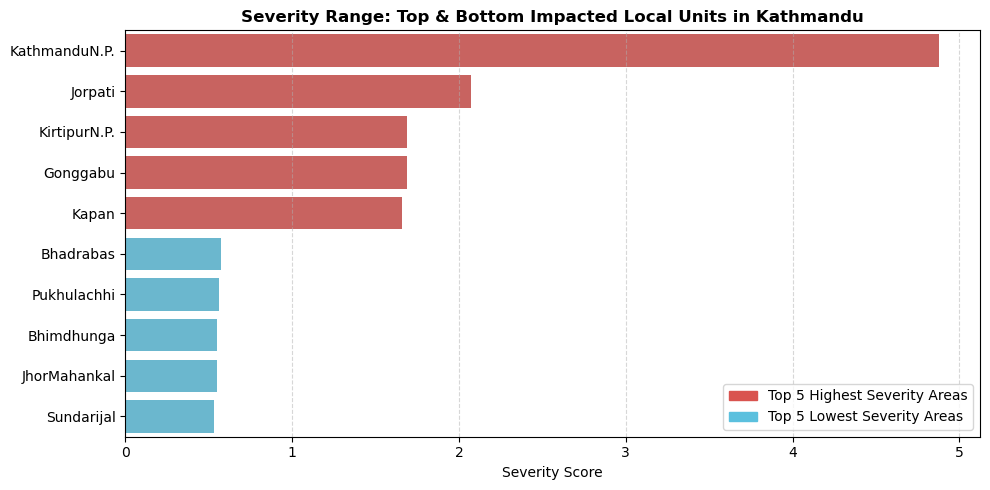

In [55]:
##########step 5
import matplotlib.patches as mpatches

# 1. Get top 5 highest and top 5 lowest local units by severity score
top_5 = clean_table_sorted.head(5)
bottom_5 = clean_table_sorted.tail(5)

# 2. Combine them into one clean plotting dataframe
plot_df = pd.concat([top_5, bottom_5]).drop_duplicates()

# 3. Build the horizontal bar chart
plt.figure(figsize=(10, 5))

# Assign colors: Intense red for top 5, calm blue for bottom 5
colors = ['#d9534f'] * len(top_5) + ['#5bc0de'] * len(bottom_5)
colors = colors[:len(plot_df)] # Adjust if there are fewer than 10 units total

sns.barplot(
    data=plot_df, 
    x="Severity", 
    y="Local Unit (Municipality/VDC)", 
    palette=colors
)

# --- THE LEGEND ADDITION ---
# Create custom colored squares to represent our labels
red_patch = mpatches.Patch(color='#d9534f', label='Top 5 Highest Severity Areas')
blue_patch = mpatches.Patch(color='#5bc0de', label='Top 5 Lowest Severity Areas')

# Place the legend box neatly inside the graph (upper right corner)
plt.legend(handles=[red_patch, blue_patch], loc='lower right', frameon=True)
# ---------------------------

plt.title(f"Severity Range: Top & Bottom Impacted Local Units in {test_district}", fontsize=12, fontweight='bold')
plt.xlabel("Severity Score")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Show the plot cleanly in your notebook
plt.tight_layout()
plt.show()

----------blog------qn

In [56]:
# 3. Filter the data for that district and select the key columns

pd.set_option('display.max_rows', None)

district_factors = df[df["DISTRICT"] == 'Syangja'][
    ["VDC_NAME"]
]
print(district_factors)

                 VDC_NAME
1395      PutalibazarN.P.
1571           WalingN.P.
1664               Sakhar
1681               Sekham
1728            Fedikhola
1748             Ratnapur
1847               Kyakmi
1880    Chisapani(Magyam)
1909               Taksar
1979            Chinnebas
1981              Kichnas
1993               Sworek
1998             Chapakot
2006      DarsingDahathum
2011           Pauwegaude
2013            Arukharka
2027          Jagatradevi
2034           Malyangkot
2040              Pakwadi
2041      Chitrebhanjyang
2047            Thuladihi
2048           Manakamana
2050               Oraste
2053          Thumpokhara
2074              Kuwakot
2077  ShreekrishnaGandaki
2079       Arjun Chaupari
2080              Pelakot
2099       Chhangchhangdi
2111            Tindobate
2113       Khilungdeurali
2117        BiruwaArchale
2123       Jagatbhanjyang
2135             Rangvang
2136            Panchamul
2143            Pidikhola
2146      BenethokDeurali
2150        

In [57]:
# Calculate basic summary statistics for the Hazard column
hazard_summary = df["Hazard (Intensity)"].describe()
hazard_summary

count    3985.000000
mean        0.320537
std         0.779937
min         0.000000
25%         0.000000
50%         0.010000
75%         0.130000
max        10.000000
Name: Hazard (Intensity), dtype: float64

In [58]:
# Calculate basic summary statistics for the exposure column
exposure_summary = df["Exposure"].describe()
exposure_summary

count    3985.000000
mean        0.067493
std         0.187551
min         0.000000
25%         0.030000
50%         0.050000
75%         0.070000
max        10.000000
Name: Exposure, dtype: float64

In [59]:
# Calculate basic summary statistics for the housing column
housing_summary = df["Housing"].describe()
housing_summary

count    3985.000000
mean        5.706522
std         1.953037
min         1.170000
25%         4.640000
50%         5.610000
75%         6.850000
max         9.940000
Name: Housing, dtype: float64

In [60]:
# 1. Get the Top 5 HIGHEST housing vulnerability rows
top_5_high_housing = df.sort_values(by="Housing", ascending=False).head(5)

# 2. Get the Top 5 LOWEST housing vulnerability rows
top_5_low_housing = df.sort_values(by="Housing", ascending=True).head(5)

print("---  TOP 5 HIGHEST HOUSING  ---")
print(top_5_high_housing[["DISTRICT", "VDC_NAME", "Hazard (Intensity)", "Exposure", "Housing", "Poverty", "Severity"]])

print("\n--- TOP 5 LOWEST HOUSING  ---")
print(top_5_low_housing[["DISTRICT", "VDC_NAME", "Hazard (Intensity)", "Exposure", "Housing", "Poverty", "Severity"]])

---  TOP 5 HIGHEST HOUSING  ---
     DISTRICT      VDC_NAME  Hazard (Intensity)  Exposure  Housing  Poverty  \
3644  Baitadi  Dhikarim/Rim                 0.0      0.04     9.94     3.31   
3672  Baitadi      Giregada                 0.0      0.03     9.94     3.31   
3650  Baitadi        Sikash                 0.0      0.04     9.94     3.31   
3651  Baitadi     Bijayapur                 0.0      0.04     9.94     3.31   
3652  Baitadi       Bhatana                 0.0      0.04     9.94     3.31   

      Severity  
3644       0.0  
3672       0.0  
3650       0.0  
3651       0.0  
3652       0.0  

--- TOP 5 LOWEST HOUSING  ---
     DISTRICT      VDC_NAME  Hazard (Intensity)  Exposure  Housing  Poverty  \
1992  Saptari      Rupnagar                0.01      0.05     1.17     6.67   
1960  Saptari   Bhagawatpur                0.02      0.05     1.17     6.67   
1959  Saptari      Terahota                0.01      0.05     1.17     6.67   
1958  Saptari     Bathanaha                0

In [61]:
# 1. Get the real summary stats for the Poverty column
print("--- National Poverty Statistics ---")
print(df["Poverty"].describe())

# 2. Check the correlation between Housing and Poverty
# This outputs a number between -1 and 1. 
# A score close to 0 means they are completely independent, not connected!
correlation = df["Housing"].corr(df["Poverty"])
print(f"\nMathematical correlation between Housing and Poverty: {correlation:.4f}")

--- National Poverty Statistics ---
count    3985.000000
mean        5.481854
std         2.270975
min         0.000000
25%         3.330000
50%         5.620000
75%         7.350000
max        10.000000
Name: Poverty, dtype: float64

Mathematical correlation between Housing and Poverty: -0.0616


In [62]:
# Calculate basic summary statistics for the housing column
vulnerability_summary = df["Vulnerability"].describe()
vulnerability_summary

count    3985.000000
mean        5.594635
std         1.450817
min         1.620000
25%         4.590000
50%         5.550000
75%         6.660000
max         8.830000
Name: Vulnerability, dtype: float64

In [63]:
# Calculate basic summary statistics for the housing column
severity_summary = df["Severity"].describe()
severity_summary

count    3985.000000
mean        0.248720
std         0.298756
min         0.000000
25%         0.050000
50%         0.140000
75%         0.360000
max         4.880000
Name: Severity, dtype: float64

In [64]:
#to find the ranges
df.groupby("Severity category")["Severity"].agg(["min","max"])

,min,max
Severity category,,
High,0.84,1.44
Highest,1.48,4.88
Low,0.12,0.29
Lowest,0.00,0.12
Medium-High,0.53,0.84
Medium-Low,0.29,0.53


In [65]:
kathmandu_data = df[df["DISTRICT"] == "Kathmandu"].head(3) # i wamma know what actually features are..housing vulnerability so if kathmandu has what kind of value
kathmandu_data

,P_CODE,VDC_NAME,DISTRICT,REGION,Hazard (Intensity),Exposure,Housing,Poverty,Vulnerability,Severity,Severity Normalized,Severity category
0,C-BAG-27-031,KathmanduN.P.,Kathmandu,Central,2.17,10.00,8.86,1.82,5.34,4.88,10.0000,Highest
4,C-BAG-27-028,Jorpati,Kathmandu,Central,1.91,0.87,8.86,1.82,5.34,2.07,4.2407,Highest
9,C-BAG-27-033,KirtipurN.P.,Kathmandu,Central,1.35,0.67,8.86,1.82,5.34,1.69,3.4689,Highest


In [66]:
# seeing ktm is not only fine ..we must see another data like a poor district to compare
kathmandu_data = df[df["DISTRICT"] == "Gorkha"].head(3) # i wamma know what actually features are..housing vulnerability so if kathmandu has what kind of value
kathmandu_data

,P_CODE,VDC_NAME,DISTRICT,REGION,Hazard (Intensity),Exposure,Housing,Poverty,Vulnerability,Severity,Severity Normalized,Severity category
6,W-GAN-36-050,PrithbinarayanN.P.,Gorkha,Western,3.48,0.33,6.44,5.21,5.83,1.89,3.8764,Highest
63,W-GAN-36-041,Manakamana,Gorkha,Western,3.32,0.06,6.44,5.21,5.83,1.07,2.1987,High
67,W-GAN-36-012,Bunkot,Gorkha,Western,3.21,0.06,6.44,5.21,5.83,1.06,2.1788,High


In [67]:
kathmandu_data = df[df["DISTRICT"] == "Syangja"].head(3) # i wamma know what actually features are..housing vulnerability so if kathmandu has what kind of value
kathmandu_data

,P_CODE,VDC_NAME,DISTRICT,REGION,Hazard (Intensity),Exposure,Housing,Poverty,Vulnerability,Severity,Severity Normalized,Severity category
1395,W-GAN-39-044,PutalibazarN.P.,Syangja,Western,0.01,0.31,5.2,4.88,5.04,0.26,0.5334,Low
1571,W-GAN-39-060,WalingN.P.,Syangja,Western,0.01,0.25,5.2,4.88,5.04,0.21,0.4399,Low
1664,W-GAN-39-048,Sakhar,Syangja,Western,0.03,0.05,5.2,4.88,5.04,0.19,0.3968,Low


In [68]:
kathmandu_data = df[df["DISTRICT"] == "Sindhupalchok"].head(3) # i wamma know what actually features are..housing vulnerability so if kathmandu has what kind of value
kathmandu_data

,P_CODE,VDC_NAME,DISTRICT,REGION,Hazard (Intensity),Exposure,Housing,Poverty,Vulnerability,Severity,Severity Normalized,Severity category
101,C-BAG-23-058,Sangachok,Sindhupalchok,Central,1.47,0.10,6.85,6.57,6.71,0.99,2.0287,High
222,C-BAG-23-077,ThuloSirubari,Sindhupalchok,Central,1.28,0.06,6.85,6.57,6.71,0.81,1.6557,Medium-High
239,C-BAG-23-014,Choutara,Sindhupalchok,Central,1.21,0.06,6.85,6.57,6.71,0.79,1.6231,Medium-High


In [69]:
kathmandu_data = df[df["DISTRICT"] == "Parsa"].head(3) # i wamma know what actually features are..housing vulnerability so if kathmandu has what kind of value
kathmandu_data

,P_CODE,VDC_NAME,DISTRICT,REGION,Hazard (Intensity),Exposure,Housing,Poverty,Vulnerability,Severity,Severity Normalized,Severity category
123,C-NAR-34-020,BirgunjN. P.,Parsa,Central,0.11,1.39,4.85,6.07,5.46,0.95,1.9481,High
741,C-NAR-34-021,Birwaguthi,Parsa,Central,0.13,0.14,4.85,6.07,5.46,0.46,0.9489,Medium-Low
848,C-NAR-34-080,Thori,Parsa,Central,0.17,0.07,4.85,6.07,5.46,0.41,0.8423,Medium-Low


In [70]:
kathmandu_data = df[df["DISTRICT"] == "Manang"].head(3) # i wamma know what actually features are..housing vulnerability so if kathmandu has what kind of value
kathmandu_data

,P_CODE,VDC_NAME,DISTRICT,REGION,Hazard (Intensity),Exposure,Housing,Poverty,Vulnerability,Severity,Severity Normalized,Severity category
2026,W-GAN-41-003,Dharapani,Manang,Western,0.06,0.01,4.44,2.75,3.6,0.13,0.2731,Low
2270,W-GAN-41-002,Chame,Manang,Western,0.02,0.01,4.44,2.75,3.6,0.09,0.1829,Lowest
2309,W-GAN-41-013,Thoche,Manang,Western,0.04,0.00,4.44,2.75,3.6,0.08,0.1739,Lowest


In [71]:
kathmandu_data = df[df["DISTRICT"] == "Kaski"].head(3) # i wamma know what actually features are..housing vulnerability so if kathmandu has what kind of value
kathmandu_data

,P_CODE,VDC_NAME,DISTRICT,REGION,Hazard (Intensity),Exposure,Housing,Poverty,Vulnerability,Severity,Severity Normalized,Severity category
89,W-GAN-40-032,Pokhara N. P.,Kaski,Western,0.11,2.62,7.44,0.0,3.72,1.01,2.0704,High
411,W-GAN-40-022,Lekhnath N. P.,Kaski,Western,0.13,0.60,7.44,0.0,3.72,0.66,1.3596,Medium-High
1423,W-GAN-40-039,Sarangkot,Kaski,Western,0.05,0.09,7.44,0.0,3.72,0.25,0.5152,Low


In [72]:
order = [
    "Lowest",
    "Low",
    "Medium-Low",
    "Medium-High",
    "High",
    "Highest"
]

df["Severity category"] = pd.Categorical(
    df["Severity category"],
    categories=order,
    ordered=True
)

result = (
    df.groupby("Severity category")["Severity"]
    .agg(["min", "max"])
    .sort_index()
)

print(result)

                    min   max
Severity category            
Lowest             0.00  0.12
Low                0.12  0.29
Medium-Low         0.29  0.53
Medium-High        0.53  0.84
High               0.84  1.44
Highest            1.48  4.88


C:\Users\PC\AppData\Local\Temp\ipykernel_10608\1366068625.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Severity category")["Severity"]


-------------lets watch places according to severity----------

In [73]:
# 1. Find the row with the absolute lowest severity score
most_low_severity = df.loc[df["Severity"].idxmin()] #idxmin finds the index of min severity so loc is uded to turn row

# 2. Find the row with the absolute highest severity score
most_high_severity = df.loc[df["Severity"].idxmax()]

print("--- ABSOLUTE LOWEST SEVERITY UNIT ---")
print(most_low_severity[["DISTRICT", "VDC_NAME", "Hazard (Intensity)", "Exposure", "Housing", "Poverty", "Severity"]])

print("\n--- ABSOLUTE HIGHEST SEVERITY UNIT ---")
print(most_high_severity[["DISTRICT", "VDC_NAME", "Hazard (Intensity)", "Exposure", "Housing", "Poverty", "Severity"]])

--- ABSOLUTE LOWEST SEVERITY UNIT ---
DISTRICT                             Doti
VDC_NAME              DipayalSilgadhiN.P.
Hazard (Intensity)                    0.0
Exposure                             0.24
Housing                              8.77
Poverty                              8.26
Severity                              0.0
Name: 3304, dtype: object

--- ABSOLUTE HIGHEST SEVERITY UNIT ---
DISTRICT                  Kathmandu
VDC_NAME              KathmanduN.P.
Hazard (Intensity)             2.17
Exposure                       10.0
Housing                        8.86
Poverty                        1.82
Severity                       4.88
Name: 0, dtype: object


In [74]:
# Group by region and calculate the average score for all major columns
region_summary = df.groupby("REGION")[["Hazard (Intensity)", "Exposure", "Housing", "Poverty", "Severity"]].mean()

print("--- REGION-BASED AVERAGE DATA ---")
print(region_summary.round(2))

--- REGION-BASED AVERAGE DATA ---
             Hazard (Intensity)  Exposure  Housing  Poverty  Severity
REGION                                                               
Central                    0.90      0.08     5.74     6.04      0.56
Eastern                    0.01      0.07     3.57     5.31      0.11
Far-Western                0.00      0.07     8.23     6.33      0.00
Mid-Western                0.00      0.06     6.35     6.71      0.04
Western                    0.19      0.06     6.31     3.68      0.20


In [75]:
# Sort the data by Hazard (Intensity) from highest to lowest and grab the top 5
top_5_intensity = df.sort_values(by="Hazard (Intensity)", ascending=False).head(5)

print("--- 5 AREAS WITH THE HIGHEST EARTHQUAKE INTENSITY ---")
print(top_5_intensity[["DISTRICT", "VDC_NAME", "Hazard (Intensity)", "Exposure", "Housing", "Poverty", "Severity"]])

--- 5 AREAS WITH THE HIGHEST EARTHQUAKE INTENSITY ---
          DISTRICT        VDC_NAME  Hazard (Intensity)  Exposure  Housing  \
13        Sindhuli    Mahadevsthan               10.00      0.07     5.19   
23        Sindhuli    Dadiguranshe                9.30      0.05     5.19   
8         Sindhuli       Kapilakot                8.02      0.12     5.19   
14        Sindhuli  Kalpabrishykha                7.10      0.10     5.19   
48  Kavrepalanchok          Gokule                6.13      0.05     6.46   

    Poverty  Severity  
13     6.55      1.61  
23     6.55      1.39  
8      6.55      1.77  
14     6.55      1.59  
48     3.31      1.14  


not show cause data seems not legit

In [76]:
# Group by District and calculate average metrics for each
district_analysis = df.groupby("DISTRICT")[["Severity", "Hazard (Intensity)", "Exposure", "Housing", "Poverty"]].mean()

# Sort by Severity from highest to lowest so the most critical districts are at the top
district_analysis = district_analysis.sort_values(by="Severity", ascending=True).round(2).reset_index().head(5)

print("---  DISTRICT-BASED SEVERITY RANKING ---")
print(district_analysis)

---  DISTRICT-BASED SEVERITY RANKING ---
       DISTRICT  Severity  Hazard (Intensity)  Exposure  Housing  Poverty
0        Achham       0.0                 0.0      0.03     8.45     9.21
1  Arghakhanchi       0.0                 0.0      0.05     6.12     3.32
2       Baitadi       0.0                 0.0      0.04     9.94     3.31
3       Bajhang       0.0                 0.0      0.04     8.74     7.05
4    Kanchanpur       0.0                 0.0      0.22     5.46     3.08


the severity category according to region

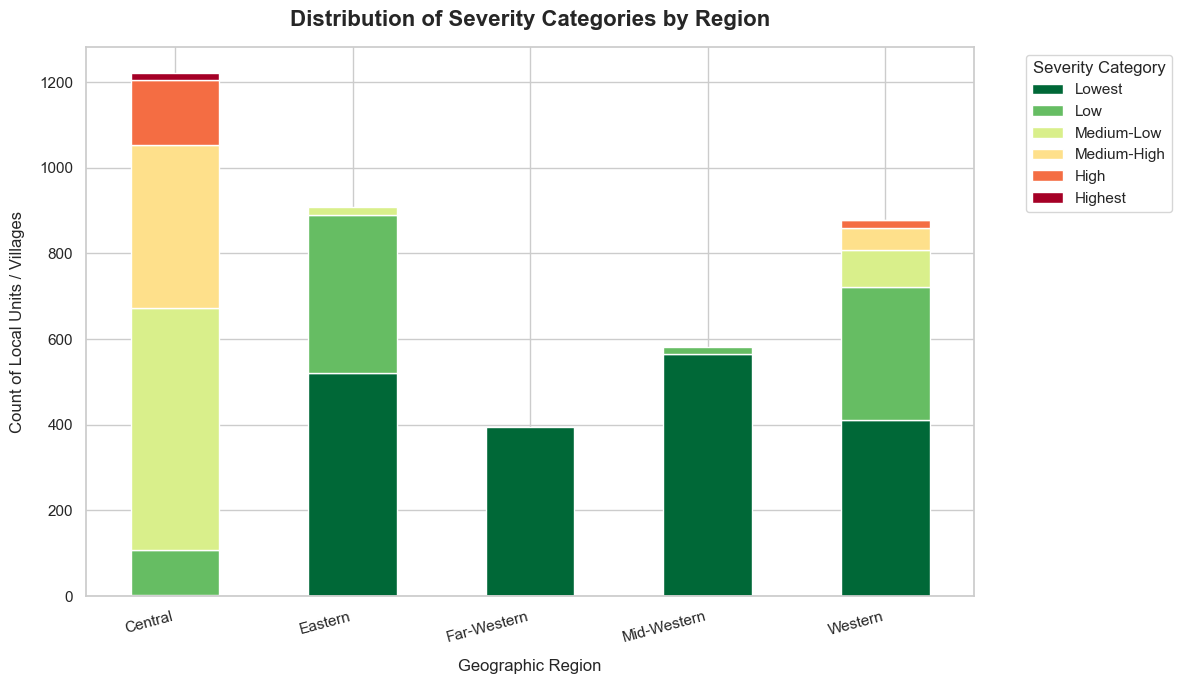

In [77]:
# 1. Unstack the data to format it perfectly for plotting
# This transforms your grouped data into a clean table format where rows = Regions and columns = Categories
region_counts = df.groupby("REGION")["Severity category"].value_counts().unstack().fillna(0)

# 2. Set up the plotting style and size
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

# 3. Create a Stacked Bar Chart
region_counts.plot(kind="bar", stacked=True, ax=ax, cmap="RdYlGn_r") # A nice Red-Yellow-Green color palette

# 4. Add clear, professional styling
plt.title("Distribution of Severity Categories by Region", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Geographic Region", fontsize=12, labelpad=10)
plt.ylabel("Count of Local Units / Villages", fontsize=12, labelpad=10)
plt.xticks(rotation=15, ha='right', fontsize=11) # Tilts region names slightly so they don't overlap

# 5. Position the legend neatly outside the chart area
plt.legend(title="Severity Category", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

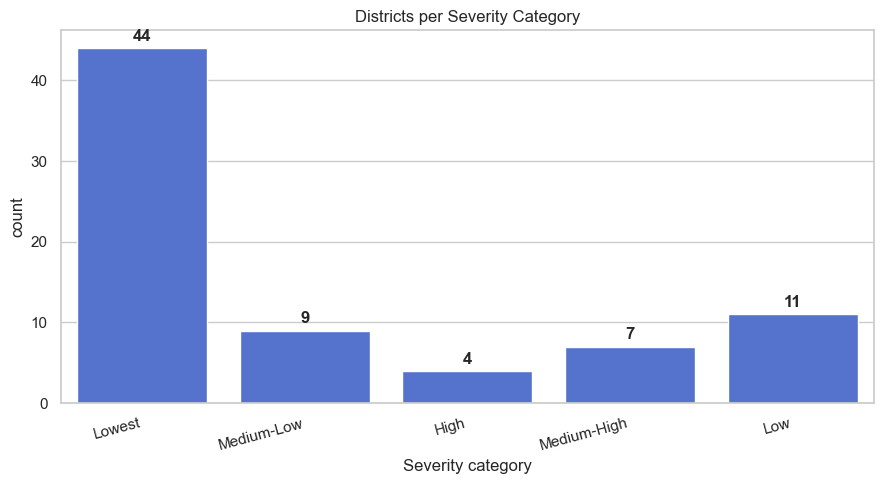

In [78]:
# 1. Clean data aggregation (1 row per district)
district_df = df.groupby("DISTRICT", as_index=False)["Severity category"].agg(lambda x: x.mode()[0])

# 2. Minimalist Countplot
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=district_df, x="Severity category", color="royalblue")

# 3. Add counts on top of each bar
ax.bar_label(ax.containers[0], fontweight='bold', padding=3)

plt.xticks(rotation=15, ha='right')
plt.title("Districts per Severity Category")
plt.tight_layout()
plt.show()

In [81]:
# Calculate average severity by district
district_avg = df.groupby("DISTRICT")["Severity"].mean().sort_values(ascending=False)

# Display the numbers
print(district_avg)

DISTRICT
Bhaktapur         1.014444
Kathmandu         0.946780
Dhading           0.918400
Makwanpur         0.859545
Chitawan          0.836410
Lalitpur          0.815000
Kavrepalanchok    0.731556
Gorkha            0.687612
Nuwakot           0.656290
Sindhupalchok     0.589620
Sindhuli          0.584630
Sarlahi           0.487700
Dolakha           0.480769
Ramechhap         0.463091
Mahottari         0.446883
Tanahu            0.443404
Rasuwa            0.435556
Rautahat          0.404639
Bara              0.362828
Dhanusa           0.355392
Parsa             0.323214
Nawalparasi       0.315333
Lamjung           0.259180
Siraha            0.246574
Rupandehi         0.235278
Sunsari           0.187736
Kaski             0.185333
Kapilbastu        0.173462
Morang            0.162576
Saptari           0.156293
Okhaldhunga       0.136429
Syangja           0.120000
Udayapur          0.117778
Dang              0.109024
Palpa             0.093333
Solukhumbu        0.093235
Baglung           0

we dont have ranges so we ant find it...what i think

In [ ]:
# Sort from highest shaking intensity down and view the top 10 rows
high_intensity = df.sort_values(by="Hazard (Intensity)", ascending=False).head(10)

# Display only the main location and risk identifier columns
print(high_intensity)

           P_CODE            VDC_NAME        DISTRICT   REGION  \
13   C-JAN-20-034        Mahadevsthan        Sindhuli  Central   
23   C-JAN-20-013        Dadiguranshe        Sindhuli  Central   
8    C-JAN-20-026           Kapilakot        Sindhuli  Central   
14   C-JAN-20-024      Kalpabrishykha        Sindhuli  Central   
48   C-BAG-24-032              Gokule  Kavrepalanchok  Central   
121  C-BAG-24-018           Dandagaun  Kavrepalanchok  Central   
122  C-JAN-20-045  Santeswori(Rampur)        Sindhuli  Central   
92   C-NAR-35-009           Dahakhani        Chitawan  Central   
91   C-NAR-35-008     ChandiBhanjyang        Chitawan  Central   
169  C-JAN-20-001               Amale        Sindhuli  Central   

     Hazard (Intensity)  Exposure  Housing  Poverty  Vulnerability  Severity  \
13                10.00      0.07     5.19     6.55           5.87      1.61   
23                 9.30      0.05     5.19     6.55           5.87      1.39   
8                  8.02      0.12

In [ ]:
# Group by Region and District, get average shaking intensity, and rank them
high_intensity_districts = df.groupby(["REGION", "DISTRICT"])["Hazard (Intensity)"].mean().reset_index()
high_intensity_districts = high_intensity_districts.sort_values(by="Hazard (Intensity)", ascending=False)

print("---  REGIONS & DISTRICTS RANKED BY SHAKING INTENSITY ---")
print(high_intensity_districts.head(10).to_string(index=False))

---  REGIONS & DISTRICTS RANKED BY SHAKING INTENSITY ---
 REGION       DISTRICT  Hazard (Intensity)
Central      Makwanpur            2.450909
Central       Lalitpur            2.427619
Central Kavrepalanchok            2.254556
Central        Dhading            2.080200
Central      Bhaktapur            1.982778
Central       Chitawan            1.715385
Central       Sindhuli            1.628148
Western         Gorkha            1.611194
Central      Kathmandu            1.426780
Central        Nuwakot            1.180806


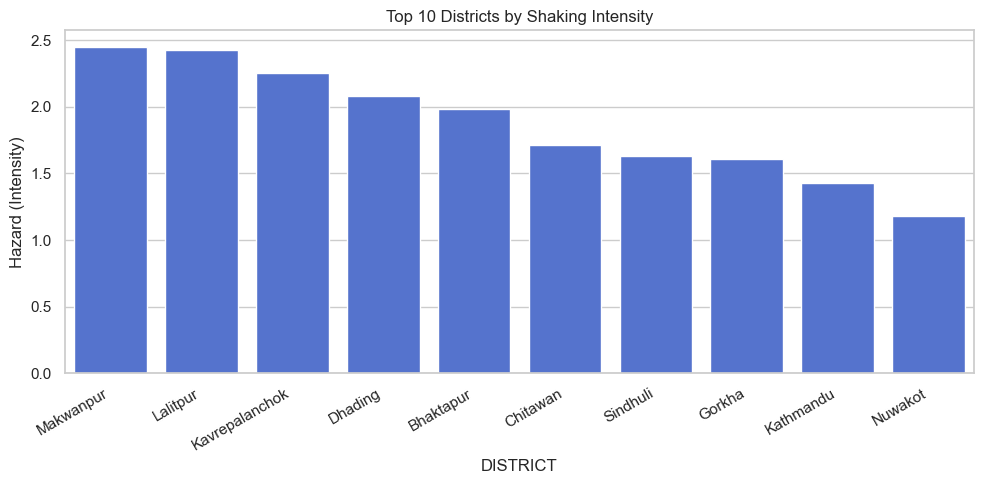

In [ ]:


# 1. Get the top 10 districts with the highest average shaking intensity
top_10 = df.groupby("DISTRICT")["Hazard (Intensity)"].mean().nlargest(10).reset_index()

# 2. Plot a clean bar graph using the short, warning-free Seaborn format
plt.figure(figsize=(10, 5))
sns.barplot(data=top_10, x="DISTRICT", y="Hazard (Intensity)", color="royalblue")

plt.xticks(rotation=30, ha='right')
plt.title("Top 10 Districts by Shaking Intensity")
plt.tight_layout()
plt.show()

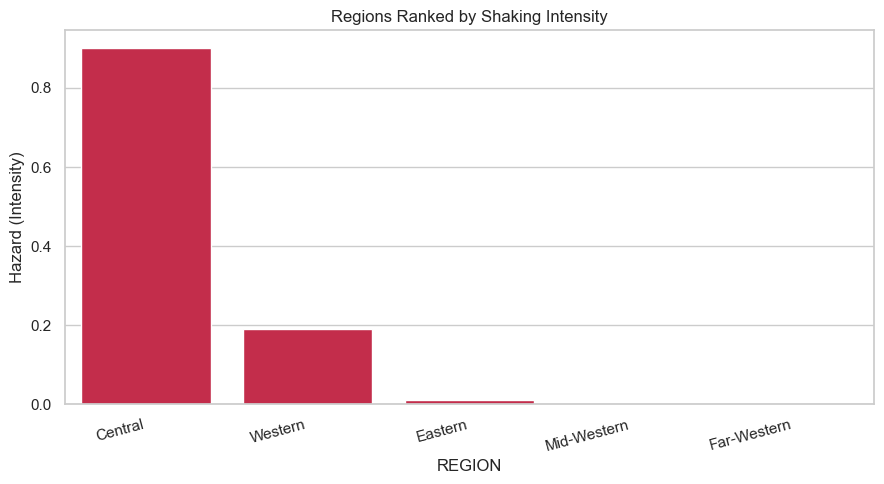

In [ ]:
region_intensity = df.groupby("REGION")["Hazard (Intensity)"].mean().sort_values(ascending=False).reset_index()

# 2. Plot a clean bar graph
plt.figure(figsize=(9, 5))
sns.barplot(data=region_intensity, x="REGION", y="Hazard (Intensity)", color="crimson")

plt.xticks(rotation=15, ha='right')
plt.title("Regions Ranked by Shaking Intensity")
plt.tight_layout()
plt.show()

i wanna see makwanpur and laitpur data as they seen high intensity

In [ ]:
# 1. Filter dataset for only Makwanpur and Lalitpur
target_df = df[df["DISTRICT"].isin(["Makwanpur", "Lalitpur"])]

# 2. Group by DISTRICT and calculate the average for ALL numeric columns automatically
# (numeric_only=True ensures text columns like VDC_NAME don't break the code!)
district_averages = target_df.groupby("DISTRICT").mean(numeric_only=True)

# 3. Print the clean summary table
district_averages

,Hazard (Intensity),Exposure,Housing,Poverty,Vulnerability,Severity,Severity Normalized
DISTRICT,,,,,,,
Lalitpur,2.427619,0.111190,8.40,0.82,4.61,0.815000,1.672479
Makwanpur,2.450909,0.096818,4.99,3.64,4.32,0.859545,1.761986
